# GAN-based Image Generation — DCGAN on CIFAR-10

This notebook trains a Deep Convolutional Generative Adversarial Network (DCGAN) using PyTorch.

**Goal:** learn a visual data distribution from CIFAR-10 and generate new 32×32 RGB images from random latent vectors.

The notebook is deliberately written step-by-step so the complete GAN workflow can be explained during an interview.

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 128
IMAGE_SIZE = 32
CHANNELS = 3
LATENT_SIZE = 100
FEATURES_G = 64
FEATURES_D = 64

LEARNING_RATE = 0.0002
BETA1 = 0.5
EPOCHS = 20

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MODEL_DIR = ROOT / "models"
OUTPUT_DIR = ROOT / "generated"
MODEL_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

print("Device:", DEVICE)
print("Project root:", ROOT)

Device: cpu
Project root: c:\Users\user\Desktop\GAN-based-Image-Generation


## 1. Load and normalize CIFAR-10

CIFAR-10 contains small RGB images. We normalize each channel to approximately `[-1, 1]` because the Generator ends with a `Tanh` activation.

100.0%


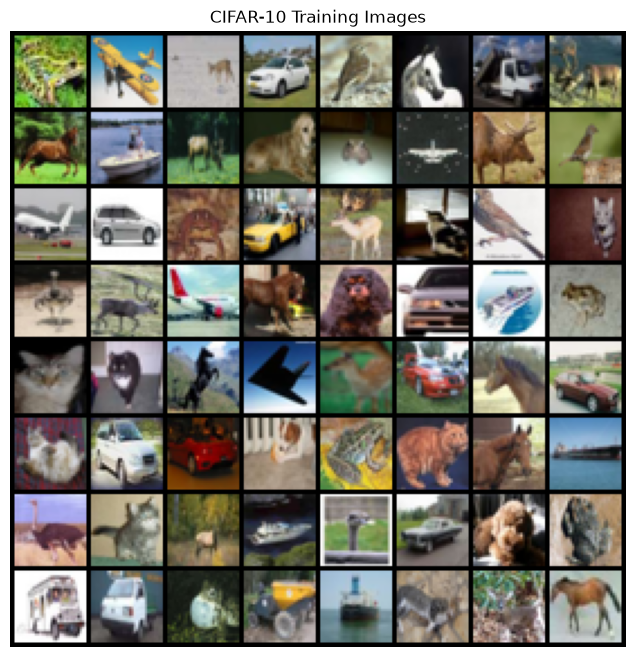

In [2]:
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

dataset = datasets.CIFAR10(
    root=ROOT / "data",
    train=True,
    download=True,
    transform=transform,
)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

real_batch, labels = next(iter(dataloader))

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("CIFAR-10 Training Images")
plt.imshow(
    np.transpose(
        make_grid(real_batch[:64], padding=2, normalize=True).cpu(),
        (1, 2, 0)
    )
)
plt.show()

## 2. Define the Generator

The Generator starts with a 100-dimensional latent vector and progressively increases its spatial size using transposed convolution layers.

For 32×32 output:

`100 × 1 × 1 → 512 × 4 × 4 → 256 × 8 × 8 → 128 × 16 × 16 → 64 × 32 × 32 → 3 × 32 × 32`

In [3]:
class Generator(nn.Module):
    def __init__(self, latent_size=100, channels=3, features=64):
        super().__init__()

        self.network = nn.Sequential(
            nn.ConvTranspose2d(latent_size, features * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(features * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(features * 8, features * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(features * 4, features * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(features * 2, features, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features),
            nn.ReLU(True),

            nn.Conv2d(features, channels, 3, 1, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, noise):
        return self.network(noise)

## 3. Define the Discriminator

The Discriminator performs binary classification. It progressively reduces a 32×32 image until it produces one logit representing how strongly the model considers the image real.

In [4]:
class Discriminator(nn.Module):
    def __init__(self, channels=3, features=64):
        super().__init__()

        self.network = nn.Sequential(
            nn.Conv2d(channels, features, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(features, features * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(features * 2, features * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(features * 4, features * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features * 8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(features * 8, 1, 2, 1, 0, bias=False),
        )

    def forward(self, image):
        return self.network(image).view(-1)

## 4. Weight initialization

The DCGAN approach initializes convolutional weights from a normal distribution and BatchNorm weights around 1. This provides a consistent starting point for the adversarial training process.

In [5]:
def weights_init(module):
    name = module.__class__.__name__

    if "Conv" in name:
        nn.init.normal_(module.weight.data, 0.0, 0.02)

    elif "BatchNorm" in name:
        nn.init.normal_(module.weight.data, 1.0, 0.02)
        nn.init.constant_(module.bias.data, 0)


generator = Generator(LATENT_SIZE, CHANNELS, FEATURES_G).to(DEVICE)
discriminator = Discriminator(CHANNELS, FEATURES_D).to(DEVICE)

generator.apply(weights_init)
discriminator.apply(weights_init)

print(generator)
print(discriminator)

Generator(
  (network): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): Conv2d(64, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1

In [6]:
criterion = nn.BCEWithLogitsLoss()

optimizer_g = optim.Adam(
    generator.parameters(),
    lr=LEARNING_RATE,
    betas=(BETA1, 0.999),
)

optimizer_d = optim.Adam(
    discriminator.parameters(),
    lr=LEARNING_RATE,
    betas=(BETA1, 0.999),
)

fixed_noise = torch.randn(64, LATENT_SIZE, 1, 1, device=DEVICE)

generator_losses = []
discriminator_losses = []
sample_images = []

## 5. Train the GAN

Each batch has two main stages:

1. **Discriminator step:** learn from real images and detached fake images.
2. **Generator step:** generate images and update the Generator so the Discriminator classifies them as real.

The notebook stores loss values and fixed-noise samples for later inspection.

In [7]:
for epoch in range(EPOCHS):
    generator.train()
    discriminator.train()

    epoch_g_loss = 0.0
    epoch_d_loss = 0.0

    for real_images, _ in dataloader:
        real_images = real_images.to(DEVICE)
        batch_size = real_images.size(0)

        # -------------------------
        # Train Discriminator
        # -------------------------
        discriminator.zero_grad(set_to_none=True)

        real_labels = torch.ones(batch_size, device=DEVICE)
        fake_labels = torch.zeros(batch_size, device=DEVICE)

        real_output = discriminator(real_images)
        loss_real = criterion(real_output, real_labels)

        noise = torch.randn(batch_size, LATENT_SIZE, 1, 1, device=DEVICE)
        fake_images = generator(noise)

        fake_output = discriminator(fake_images.detach())
        loss_fake = criterion(fake_output, fake_labels)

        d_loss = loss_real + loss_fake
        d_loss.backward()
        optimizer_d.step()

        # -------------------------
        # Train Generator
        # -------------------------
        generator.zero_grad(set_to_none=True)

        fake_output = discriminator(fake_images)
        g_loss = criterion(fake_output, real_labels)

        g_loss.backward()
        optimizer_g.step()

        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()

    epoch_d_loss /= len(dataloader)
    epoch_g_loss /= len(dataloader)

    discriminator_losses.append(epoch_d_loss)
    generator_losses.append(epoch_g_loss)

    generator.eval()
    with torch.no_grad():
        fixed_samples = generator(fixed_noise).cpu()

    sample_images.append(fixed_samples)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"D Loss: {epoch_d_loss:.4f} | "
        f"G Loss: {epoch_g_loss:.4f}"
    )

Epoch [1/20] D Loss: 0.8537 | G Loss: 3.4404
Epoch [2/20] D Loss: 0.7571 | G Loss: 3.3103
Epoch [3/20] D Loss: 0.7999 | G Loss: 3.0577
Epoch [4/20] D Loss: 0.8575 | G Loss: 2.7894
Epoch [5/20] D Loss: 0.8586 | G Loss: 2.4976
Epoch [6/20] D Loss: 0.9015 | G Loss: 2.3646
Epoch [7/20] D Loss: 0.9462 | G Loss: 2.1602
Epoch [8/20] D Loss: 0.9894 | G Loss: 1.9832
Epoch [9/20] D Loss: 0.9535 | G Loss: 2.0160
Epoch [10/20] D Loss: 0.9143 | G Loss: 2.0581
Epoch [11/20] D Loss: 0.9516 | G Loss: 1.9258
Epoch [12/20] D Loss: 0.9707 | G Loss: 1.8617
Epoch [13/20] D Loss: 0.9505 | G Loss: 1.8737
Epoch [14/20] D Loss: 0.9297 | G Loss: 1.9111
Epoch [15/20] D Loss: 0.9220 | G Loss: 1.9704
Epoch [16/20] D Loss: 0.9051 | G Loss: 1.9167
Epoch [17/20] D Loss: 0.8868 | G Loss: 1.9404
Epoch [18/20] D Loss: 0.8587 | G Loss: 1.9947
Epoch [19/20] D Loss: 0.8400 | G Loss: 2.0833
Epoch [20/20] D Loss: 0.8313 | G Loss: 2.1194


## 6. Visualize the training losses

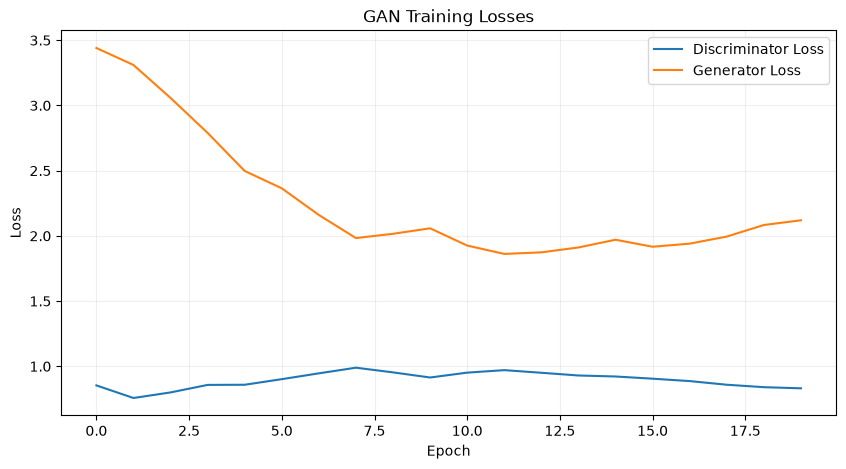

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(discriminator_losses, label="Discriminator Loss")
plt.plot(generator_losses, label="Generator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Losses")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 7. View generated images

The same fixed latent vectors are used throughout training. This makes the progression easier to compare.

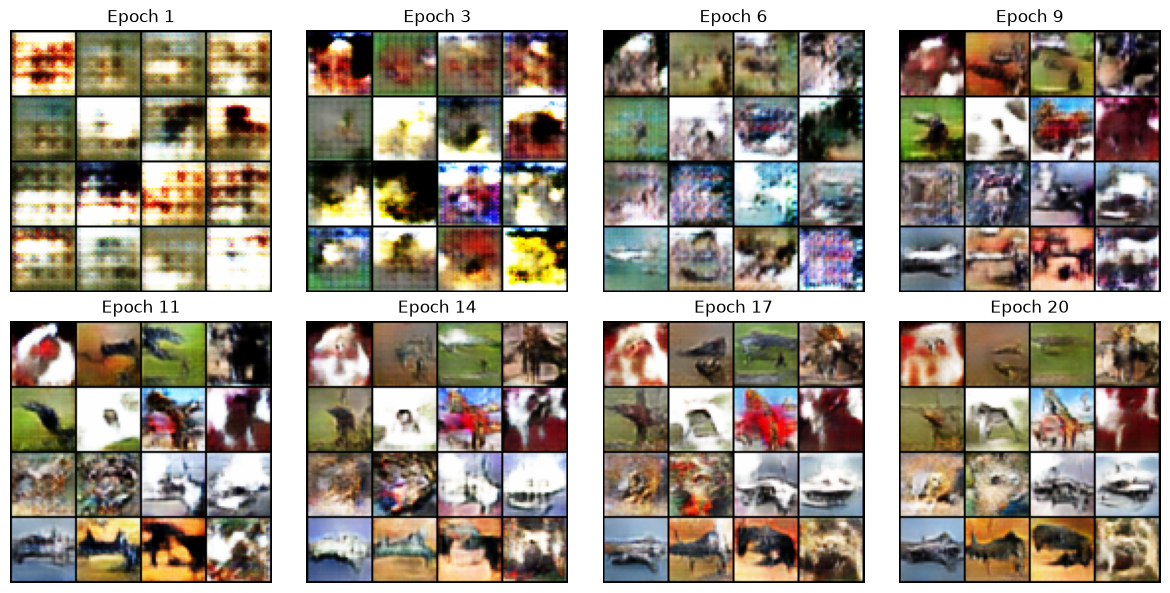

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
selected_epochs = np.linspace(0, len(sample_images) - 1, 8).astype(int)

for ax, index in zip(axes.ravel(), selected_epochs):
    grid = make_grid(sample_images[index][:16], nrow=4, normalize=True, padding=1)
    ax.imshow(np.transpose(grid, (1, 2, 0)))
    ax.set_title(f"Epoch {index + 1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 8. Save the trained checkpoints

The Generator checkpoint is loaded by the Flask application.

In [10]:
torch.save(
    {"model_state_dict": generator.state_dict()},
    MODEL_DIR / "generator.pth",
)

torch.save(
    {"model_state_dict": discriminator.state_dict()},
    MODEL_DIR / "discriminator.pth",
)

final_grid = make_grid(sample_images[-1][:32], nrow=8, normalize=True, padding=2)

from PIL import Image

final_image = transforms.ToPILImage()(final_grid)
final_image.save(OUTPUT_DIR / "final_generated_samples.png")

print("Saved:", MODEL_DIR / "generator.pth")
print("Saved:", MODEL_DIR / "discriminator.pth")
print("Saved:", OUTPUT_DIR / "final_generated_samples.png")

Saved: c:\Users\user\Desktop\GAN-based-Image-Generation\models\generator.pth
Saved: c:\Users\user\Desktop\GAN-based-Image-Generation\models\discriminator.pth
Saved: c:\Users\user\Desktop\GAN-based-Image-Generation\generated\final_generated_samples.png


## 9. Generate a fresh batch

These samples were not selected from the training set. They are generated by sampling new random latent vectors.

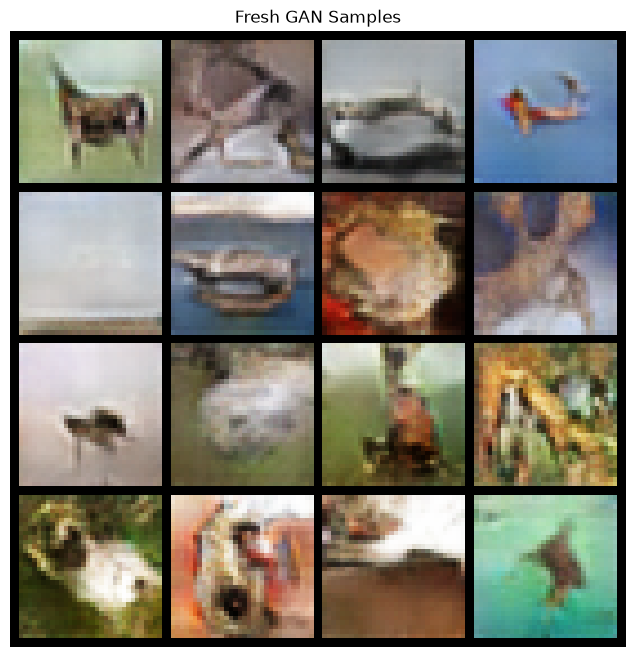

In [11]:
generator.eval()

with torch.no_grad():
    new_noise = torch.randn(16, LATENT_SIZE, 1, 1, device=DEVICE)
    new_images = generator(new_noise).cpu()

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Fresh GAN Samples")
plt.imshow(
    np.transpose(
        make_grid(new_images, nrow=4, normalize=True, padding=2),
        (1, 2, 0)
    )
)
plt.show()

## Interview Summary

Be prepared to explain:

- The role of the Generator and Discriminator.
- Why the Generator uses transposed convolutions.
- Why the Discriminator uses strided convolutions.
- Why the Generator output uses `Tanh`.
- Why images are normalized to `[-1, 1]`.
- Why `BCEWithLogitsLoss` is used.
- Why Adam uses a small learning rate and `beta1=0.5`.
- Why GAN losses can oscillate.
- What mode collapse means.
- Why visual inspection is important for GANs.
- Why a larger dataset and higher resolution would require substantially more compute.